<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Dog_Emotion_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohitagarwal17/dog-emotion-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-emotion-dataset' dataset.
Path to dataset files: /kaggle/input/dog-emotion-dataset


In [ ]:
import os

dataset_path = path + '/Dog Emotion'

os.listdir(path+'/Dog Emotion')


['angry', 'sad', 'relaxed', 'happy', 'labels.csv']

In [ ]:
import pandas as pd
labels =pd.DataFrame(pd.read_csv(path+'/Dog Emotion/labels.csv'))
labels.head()

,Unnamed: 0,filename,label
0,0,yubL63eiiPmoRru8Z2K2yRo0NnGDCL683.jpg,sad
1,1,c1tVljKiLM9q2zTBuQGWpxmzBuSeBR437.jpg,sad
2,2,RbzNOvY5GIAl3PSjIRTKpEkQs1NByq575.jpg,angry
3,3,gKujaBuWYezz0yWK9ydTFVi6LbQtXe397.jpg,angry
4,4,U0hJ2ryOu1IOuYpc01O7RngPYa8Xvz795.jpg,relaxed


In [ ]:
print(labels.columns)

Index(['Unnamed: 0', 'filename', 'label'], dtype='object')


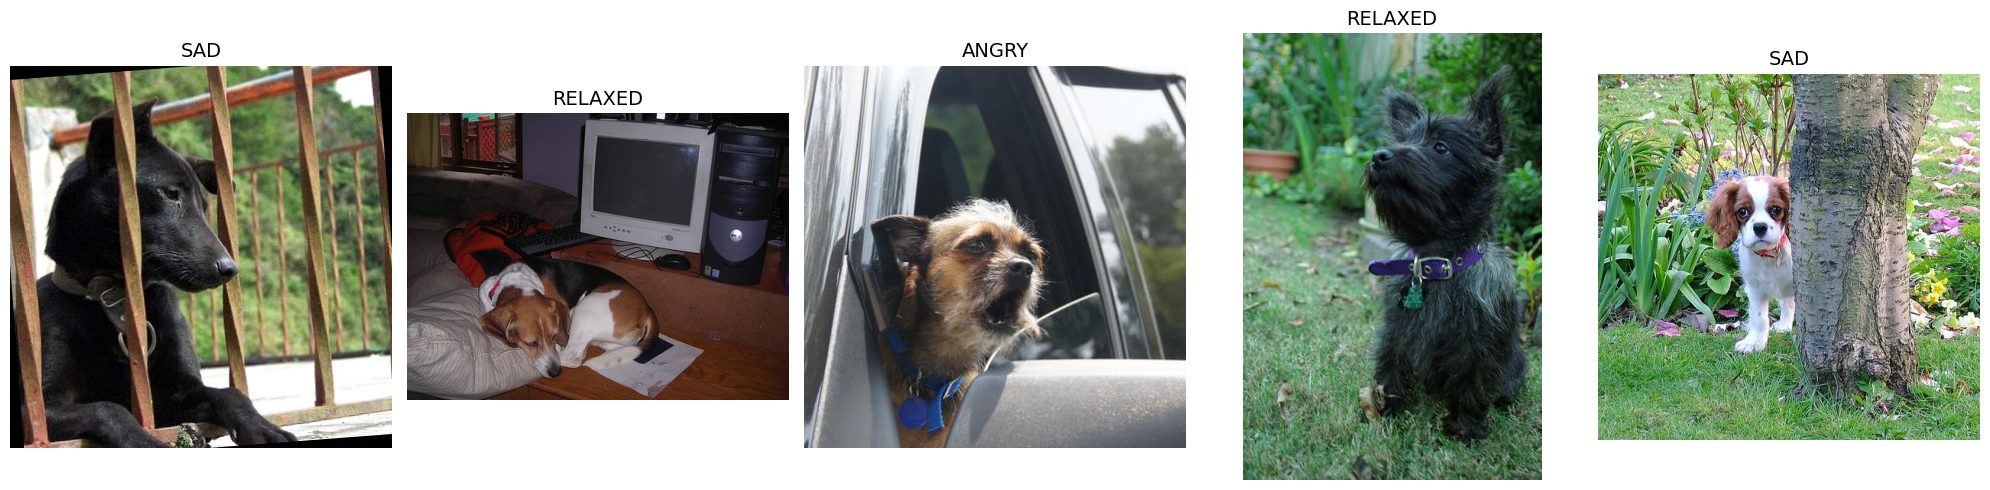

In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Seleccionar 5 imágenes al azar
samples = labels.sample(5, random_state=None)

# Crear figura
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (_, row) in zip(axes, samples.iterrows()):

    filename = row['filename']
    emotion = row['label']

    # Buscar la imagen dentro de las carpetas de emociones
    image_path = os.path.join(dataset_path, emotion, filename)

    # Cargar imagen
    image = Image.open(image_path)

    # Mostrar
    ax.imshow(image)
    ax.set_title(emotion.upper(), fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from fastai.vision.all import *

files = get_image_files(dataset_path)

train_files, test_files = train_test_split(files, test_size=0.2, random_state=42)

print(len(train_files), len(test_files))

3158 790


In [ ]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=noop,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,

    item_tfms=[
        Resize(224, method='pad', pad_mode='reflection')
    ],

    batch_tfms=aug_transforms(
        mult=1.0,
        do_flip=True,
        flip_vert=False,
        max_rotate=10.0,
        min_zoom=1.0,
        max_zoom=1.1,
        max_lighting=0.2,
        max_warp=0.1
    )
).dataloaders(train_files, bs=4)

In [ ]:
learn = vision_learner(dls,
                       'convnextv2_base',
                       loss_func=LabelSmoothingCrossEntropy(),
                       metrics=error_rate,
                       wd=0.1).to_fp16()

model.safetensors: reconstructing file:   0%|          |  0.00B /  355MB            

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
from fastai.callback.tracker import SaveModelCallback

learn.fine_tune(
    10,
    base_lr=1e-3,
    cbs=SaveModelCallback(
        monitor='valid_loss',
        fname='best_phase1'
    )
)

epoch,train_loss,valid_loss,error_rate,time
0,1.611946,1.183122,0.429477,01:39


Better model found at epoch 0 with valid_loss value: 1.1831222772598267.


epoch,train_loss,valid_loss,error_rate,time
0,1.286435,0.924639,0.304279,02:21
1,1.233772,0.854104,0.259905,02:17
2,1.003895,0.766221,0.217116,02:18
3,0.954507,0.703438,0.191759,02:17
4,0.833431,0.666928,0.150555,02:18
5,0.760759,0.652596,0.137876,02:18
6,0.761053,0.668254,0.148970,02:18
7,0.752731,0.629476,0.141046,02:17
8,0.665250,0.630637,0.136292,02:23
9,0.694458,0.617379,0.128368,02:27


Better model found at epoch 0 with valid_loss value: 0.9246391654014587.
Better model found at epoch 1 with valid_loss value: 0.8541038036346436.
Better model found at epoch 2 with valid_loss value: 0.7662208676338196.
Better model found at epoch 3 with valid_loss value: 0.703437864780426.
Better model found at epoch 4 with valid_loss value: 0.6669275164604187.
Better model found at epoch 5 with valid_loss value: 0.6525956988334656.
Better model found at epoch 7 with valid_loss value: 0.6294756531715393.
Better model found at epoch 9 with valid_loss value: 0.6173794865608215.


In [ ]:
from fastai.callback.all import GradientAccumulation

learn.load('best_phase1')
learn.unfreeze()

learn.fit_one_cycle(
    5,
    lr_max=slice(1e-6, 3e-4),
    cbs=[
        SaveModelCallback(monitor='valid_loss', fname='best_phase2'),
        GradientAccumulation(n_acc=4)
    ]
)

/usr/local/lib/python3.13/dist-packages/fastai/learner.py:68: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


epoch,train_loss,valid_loss,error_rate,time
0,0.674517,0.615506,0.128368,02:17
1,0.700155,0.637314,0.145800,02:18
2,0.656648,0.616542,0.129952,02:19
3,0.670802,0.612300,0.118859,02:18
4,0.611505,0.619791,0.123613,02:18


Better model found at epoch 0 with valid_loss value: 0.6155062913894653.
Better model found at epoch 3 with valid_loss value: 0.6122995615005493.


In [ ]:
test_dl = dls.test_dl(test_files, with_labels=True)
loss, err = learn.validate(dl=test_dl)
accuracy = (1-err)*100
print(f"Test Images: {len(test_files)}")
print(f"Correct Predictions: {round(accuracy*len(test_files)/100)}")
print(f"Incorrect Predictions: {len(test_files)-round(accuracy*len(test_files)/100)}")
print(f"Accuracy: {accuracy:.2f}%")

Test Images: 790
Correct Predictions: 688
Incorrect Predictions: 102
Accuracy: 87.09%


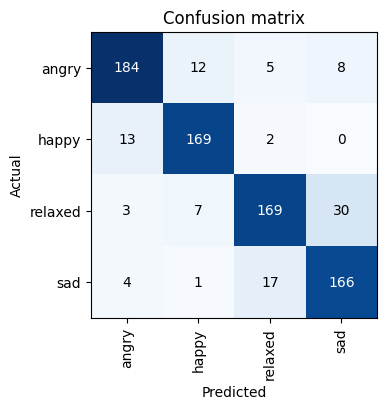

In [ ]:
interp = ClassificationInterpretation.from_learner(
    learn,
    dl=test_dl)
interp.plot_confusion_matrix(figsize=(4,4))


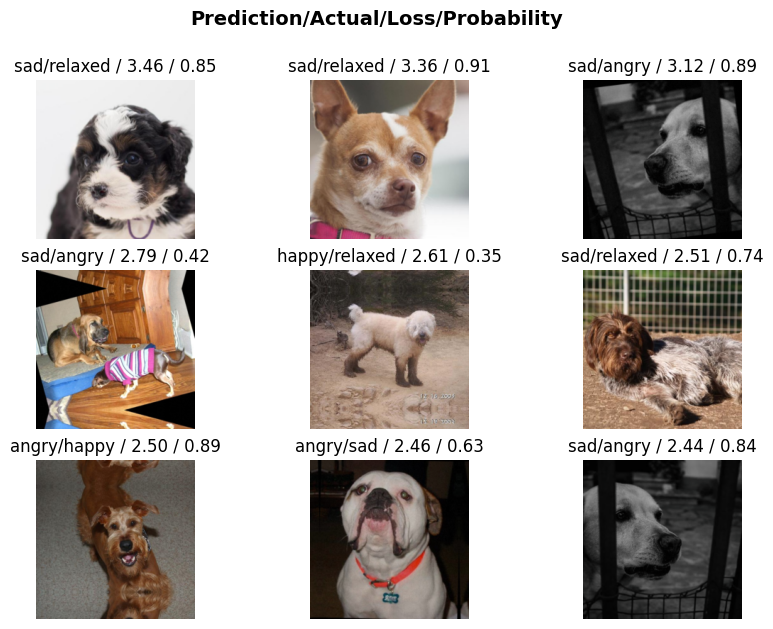

In [ ]:
interp.plot_top_losses(9, figsize=(10,7))

In [ ]:
from sklearn.metrics import classification_report

preds, targs = learn.tta(dl=test_dl)

y_pred = preds.argmax(dim=1).numpy()
y_true = targs.numpy()

print(classification_report(
    y_true,
    y_pred,
    target_names=dls.vocab
))

epoch,train_loss,valid_loss,error_rate,time


<div></div>

              precision    recall  f1-score   support

       angry       0.92      0.88      0.90       209
       happy       0.90      0.92      0.91       184
     relaxed       0.87      0.80      0.83       209
         sad       0.80      0.88      0.84       188

    accuracy                           0.87       790
   macro avg       0.87      0.87      0.87       790
weighted avg       0.87      0.87      0.87       790



In [ ]:
from pathlib import Path

dataset_path = Path(path) / "Dog Emotion"

def buscar_imagen(filename):
    resultados = list(dataset_path.rglob(filename))

    if len(resultados) > 0:
        return resultados[0]

    return None

labels["filepath"] = labels["filename"].apply(buscar_imagen)

labels.head()

,Unnamed: 0,filename,label,filepath
0,0,yubL63eiiPmoRru8Z2K2yRo0NnGDCL683.jpg,sad,/kaggle/input/dog-emotion-dataset/Dog Emotion/sad/yubL63eiiPmoRru8Z2K2yRo0NnGDCL683.jpg
1,1,c1tVljKiLM9q2zTBuQGWpxmzBuSeBR437.jpg,sad,/kaggle/input/dog-emotion-dataset/Dog Emotion/sad/c1tVljKiLM9q2zTBuQGWpxmzBuSeBR437.jpg
2,2,RbzNOvY5GIAl3PSjIRTKpEkQs1NByq575.jpg,angry,/kaggle/input/dog-emotion-dataset/Dog Emotion/angry/RbzNOvY5GIAl3PSjIRTKpEkQs1NByq575.jpg
3,3,gKujaBuWYezz0yWK9ydTFVi6LbQtXe397.jpg,angry,/kaggle/input/dog-emotion-dataset/Dog Emotion/angry/gKujaBuWYezz0yWK9ydTFVi6LbQtXe397.jpg
4,4,U0hJ2ryOu1IOuYpc01O7RngPYa8Xvz795.jpg,relaxed,/kaggle/input/dog-emotion-dataset/Dog Emotion/relaxed/U0hJ2ryOu1IOuYpc01O7RngPYa8Xvz795.jpg


In [ ]:
print(labels[["filename", "label", "filepath"]].head())

                                filename    label  \
0  yubL63eiiPmoRru8Z2K2yRo0NnGDCL683.jpg      sad   
1  c1tVljKiLM9q2zTBuQGWpxmzBuSeBR437.jpg      sad   
2  RbzNOvY5GIAl3PSjIRTKpEkQs1NByq575.jpg    angry   
3  gKujaBuWYezz0yWK9ydTFVi6LbQtXe397.jpg    angry   
4  U0hJ2ryOu1IOuYpc01O7RngPYa8Xvz795.jpg  relaxed   

                                                                                      filepath  
0      /kaggle/input/dog-emotion-dataset/Dog Emotion/sad/yubL63eiiPmoRru8Z2K2yRo0NnGDCL683.jpg  
1      /kaggle/input/dog-emotion-dataset/Dog Emotion/sad/c1tVljKiLM9q2zTBuQGWpxmzBuSeBR437.jpg  
2    /kaggle/input/dog-emotion-dataset/Dog Emotion/angry/RbzNOvY5GIAl3PSjIRTKpEkQs1NByq575.jpg  
3    /kaggle/input/dog-emotion-dataset/Dog Emotion/angry/gKujaBuWYezz0yWK9ydTFVi6LbQtXe397.jpg  
4  /kaggle/input/dog-emotion-dataset/Dog Emotion/relaxed/U0hJ2ryOu1IOuYpc01O7RngPYa8Xvz795.jpg  


In [ ]:
from fastai.vision.all import PILImage

row = labels.iloc[0]

img = PILImage.create(row["filepath"])

emotion, cl_idx, probs = learn.predict(img)

print("Archivo:", row["filename"])
print("Emoción real:", row["label"])
print("Predicción:", emotion)
print(f"Confianza: {probs[cl_idx] * 100:.2f}%")

Archivo: yubL63eiiPmoRru8Z2K2yRo0NnGDCL683.jpg
Emoción real: sad
Predicción: sad
Confianza: 94.97%


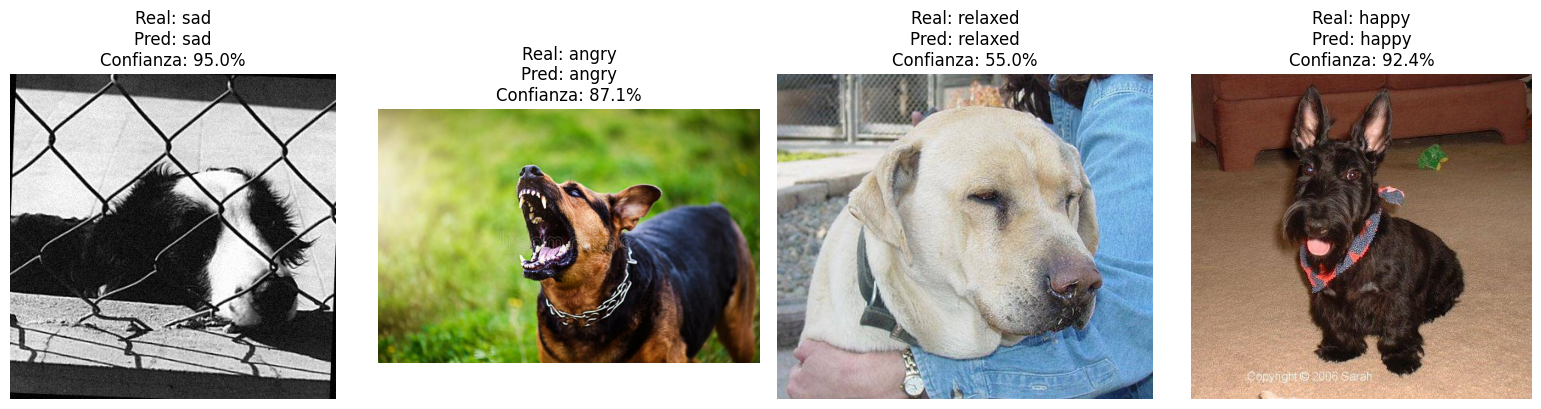

In [ ]:
import matplotlib.pyplot as plt
from fastai.vision.all import PILImage

emociones = labels["label"].unique()

fig, axes = plt.subplots(
    1,
    len(emociones),
    figsize=(16, 4)
)

for ax, emocion in zip(axes, emociones):

    # Obtener una imagen de esa emoción
    row = labels[labels["label"] == emocion].iloc[0]

    img = PILImage.create(row["filepath"])

    # Predicción
    pred, cl_idx, probs = learn.predict(img)

    # Mostrar imagen
    ax.imshow(img)
    ax.axis("off")

    ax.set_title(
        f"Real: {emocion}\n"
        f"Pred: {pred}\n"
        f"Confianza: {probs[cl_idx] * 100:.1f}%"
    )

plt.tight_layout()
plt.show()